In [1]:
import pandas as pd

df = pd.read_csv("/home/yash/Downloads/house_price_prediction_dataset_3000_fixed.csv")

In [2]:
df = df[[ 
        "area_sqft",
        "bedrooms",
        "bathrooms",
        "age_years",
        "floors",
        "location",
        "price_inr"
    ]]

In [3]:
df.head()

,area_sqft,bedrooms,bathrooms,age_years,floors,location,price_inr
0,3674,6,4.0,22,2.0,Suburban,56707000
1,4007,6,4.0,21,1.5,NaN,55874000
2,1360,2,1.0,3,2.5,Urban,21074000
3,1794,2,2.0,33,1.0,Urban,24797000
4,1630,4,3.0,5,1.0,Suburban,28868000


In [4]:
df.select_dtypes(include='number').corr()["price_inr"]

area_sqft    0.985930
bedrooms     0.899899
bathrooms    0.823199
age_years   -0.060385
floors      -0.008070
price_inr    1.000000
Name: price_inr, dtype: float64

In [5]:
df.isnull().sum()

area_sqft     0
bedrooms      0
bathrooms    60
age_years     0
floors        0
location     60
price_inr     0
dtype: int64

In [6]:
df["location"] = df["location"].fillna("Missing")
# Replace missing value of location by word "Missing".

In [7]:
print("Missing values in Location column :",df["location"].isnull().sum())

Missing values in Location column : 0


In [8]:
print(f"Bathroom Column \n\n- Mean : {df["bathrooms"].mean()}\n- Median : {df["bathrooms"].median()}\n- Mode : {df["bathrooms"].mode()}")

Bathroom Column 

- Mean : 2.7540816326530613
- Median : 3.0
- Mode : 0    4.0
Name: bathrooms, dtype: float64


In [9]:
df.select_dtypes(include='number').corr()["bathrooms"]

area_sqft    0.810623
bedrooms     0.910145
bathrooms    1.000000
age_years    0.015099
floors      -0.022828
price_inr    0.823199
Name: bathrooms, dtype: float64

In [10]:
# Split known data for training and missing data for predict their value 
train_data = df[df["bathrooms"].notna()]
missing_data = df[df["bathrooms"].isna()]

In [11]:
x_train = train_data.drop(columns=["bathrooms"])
y_train = train_data["bathrooms"]
x_pred = missing_data.drop(columns=["bathrooms"])
y_pred = missing_data["bathrooms"] # here all values are NaN because their are missing value only

In [12]:
x_train

,area_sqft,bedrooms,age_years,floors,location,price_inr
0,3674,6,22,2.0,Suburban,56707000
1,4007,6,21,1.5,Missing,55874000
2,1360,2,3,2.5,Urban,21074000
3,1794,2,33,1.0,Urban,24797000
4,1630,4,5,1.0,Suburban,28868000
...,...,...,...,...,...,...
2995,1786,3,1,1.5,Suburban,27582000
2996,3922,4,17,2.0,Rural,49741000
2997,3679,5,12,1.5,Suburban,51552000
2998,4157,5,50,1.0,Rural,50979000


In [13]:
# now apply ml model and find missing value of bathroom
from sklearn.linear_model import LogisticRegression 
lr = LogisticRegression()

In [14]:
lr.fit(x_train.drop(columns=["location"]),y_train)

/home/yash/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [15]:
y_pred = lr.predict(x_pred.drop(columns=["location"]))
y_pred.shape


(60,)

In [16]:
# now replac all missing value in df by y_pred

In [17]:
df.loc[df['bathrooms'].isna(), 'bathrooms'] = y_pred
df

,area_sqft,bedrooms,bathrooms,age_years,floors,location,price_inr
0,3674,6,4.0,22,2.0,Suburban,56707000
1,4007,6,4.0,21,1.5,Missing,55874000
2,1360,2,1.0,3,2.5,Urban,21074000
3,1794,2,2.0,33,1.0,Urban,24797000
4,1630,4,3.0,5,1.0,Suburban,28868000
...,...,...,...,...,...,...,...
2995,1786,3,2.0,1,1.5,Suburban,27582000
2996,3922,4,3.0,17,2.0,Rural,49741000
2997,3679,5,4.0,12,1.5,Suburban,51552000
2998,4157,5,3.0,50,1.0,Rural,50979000


In [18]:
df.isnull().sum()

area_sqft    0
bedrooms     0
bathrooms    0
age_years    0
floors       0
location     0
price_inr    0
dtype: int64

In [19]:
df["location"].unique()

array(['Suburban', 'Missing', 'Urban', 'Rural'], dtype=object)

(location
 Suburban    1224
 Urban       1139
 Rural        577
 Missing       60
 Name: count, dtype: int64,
 <Axes: xlabel='location'>)

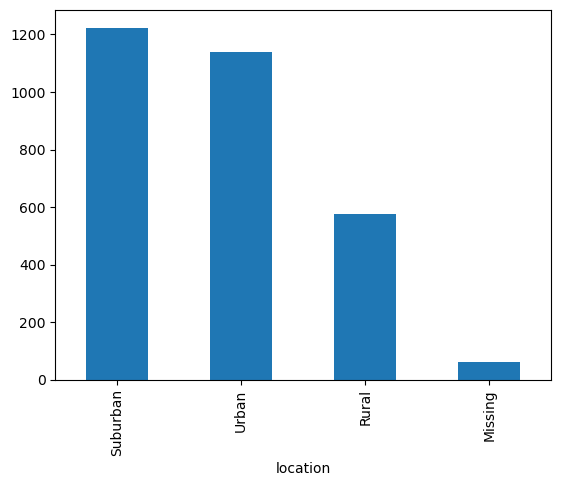

In [20]:
df["location"].value_counts(),df["location"].value_counts().plot(kind = "bar") 


In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.drop(columns=["price_inr"]),df["price_inr"],test_size=0.2,random_state=0)

In [22]:
x_train.head(),x_test.head()

(      area_sqft  bedrooms  bathrooms  age_years  floors  location
 2370       1598         3        3.0         35     2.0     Urban
 1774       1909         5        4.0         39     1.0  Suburban
 731        3569         6        4.0         39     3.0  Suburban
 271        1636         3        2.0         22     2.0  Suburban
 1077        888         2        2.0          9     1.0  Suburban,
       area_sqft  bedrooms  bathrooms  age_years  floors  location
 311         900         1        1.0         28     1.0  Suburban
 1025       1010         1        1.0          9     1.0     Urban
 1587       3572         5        3.0         14     2.5     Urban
 2941       1443         2        1.0         37     2.5     Urban
 2980       1679         2        2.0         31     1.0  Suburban)

In [23]:
# Apply Encoding to remove categorical data
from sklearn.preprocessing import OrdinalEncoder

ohe = OrdinalEncoder(categories=[['Missing', 'Rural', 'Urban', 'Suburban']])

ohe.fit(x_train[["location"]])

x_train["location"] = ohe.transform(x_train[["location"]])
x_test["location"] = ohe.transform(x_test[["location"]])

In [24]:
x_train.isnull().sum()

area_sqft    0
bedrooms     0
bathrooms    0
age_years    0
floors       0
location     0
dtype: int64

In [25]:
x_train = pd.DataFrame(x_train)
x_test = pd.DataFrame(x_test)

In [26]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

In [27]:
ss.fit(x_train)
x_train[["area_sqft","bedrooms","bathrooms","age_years","floors","location"]] = ss.transform(x_train)
x_test[["area_sqft","bedrooms","bathrooms","age_years","floors","location"]] = ss.transform(x_test)

In [28]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [29]:
lr.fit(x_train,y_train)

LinearRegression()

In [30]:
y_pred = pd.DataFrame(lr.predict(x_test))

In [31]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print("MAE       : ",mean_absolute_error(y_test,y_pred))
print("MSE       : ",mean_squared_error(y_test,y_pred))
print("R2-Score  : ",r2_score(y_test,y_pred))

MAE       :  1706932.3962578059
MSE       :  4679692999819.929
R2-Score  :  0.9782894234250104


In [32]:
from sklearn.linear_model import Ridge
r = Ridge(alpha = 15)

In [33]:
r.fit(x_train,y_train)

Ridge(alpha=15)

In [34]:
y_pred = pd.DataFrame(r.predict(x_test))

In [35]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print("MAE       : ",mean_absolute_error(y_test,y_pred))
print("MSE       : ",mean_squared_error(y_test,y_pred))
print("R2-Score  : ",r2_score(y_test,y_pred))

MAE       :  1699853.2453435147
MSE       :  4646436848148.608
R2-Score  :  0.9784437092355277
